In [1]:
# imports
import sys
import os, numpy as np
import json
import h5py, scanpy as sc
sys.path.append("../..")
from src.utils import io 
import pandas as pd
from src.utils import viz as vz
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
from matplotlib import cm
import sys
from src.training import helpers as tr_h
import random
import seaborn as sns
import importlib
import anndata as ad

import pandas as pd, numpy as np, os, sys
import anndata as ad
import logging
from typing import *
import pickle
import matplotlib.pyplot as plt
import seaborn as sns
import json
from sklearn.metrics import (
    roc_auc_score,
    roc_curve,
    auc,
    precision_recall_curve,
    average_precision_score,
)
from sklearn.metrics import confusion_matrix, classification_report
import sys
sys.path.append(os.path.join("..", ".."))
from src.utils import utils as ut
from src.utils import viz as vz
from src.utils import io 

importlib.reload(tr_h)
run_dir = os.path.join("..","..","outputs","run-25-09-17-01")
run_dir = os.path.join("..","..","outputs","run-25-09-13-18") 

if run_dir is not None:
    split_idx = 0
    # load all adata
    adata_test =  ad.read_h5ad(
    os.path.join(run_dir, f"adata_test_{split_idx+1}.h5ad"), backed="r"
    )
    adata_test.obs.reset_index(drop=True, inplace=True)  
    adata_valid =  ad.read_h5ad(
    os.path.join(run_dir, f"adata_valid_{split_idx+1}.h5ad"), backed="r"
    )
    adata_valid.obs.reset_index(drop=True, inplace=True)  
    adata_train =  ad.read_h5ad(
    os.path.join(run_dir, f"adata_train_{split_idx+1}.h5ad"), backed="r"
    )
    adata = ad.concat([adata_train, adata_valid, adata_test]).shape




/home/ddalton/Data/old_home/miniconda3/envs/scgpt_2/lib/python3.12/site-packages/anndata/_core/aligned_df.py:67: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)
/home/ddalton/Data/old_home/miniconda3/envs/scgpt_2/lib/python3.12/site-packages/anndata/_core/anndata.py:1818: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


In [2]:
pt_train_embedd = np.load("/aloy/scratch/ddalton/projects/scGPT_playground/outputs/run-25-09-13-18/train-pt_embeddings.npy")

In [3]:
import importlib
import scanpy as sc

importlib.reload(ut)
importlib.reload(vz)

split_idx = 0

# load all adata
adata_test =  sc.read(
    os.path.join(run_dir, f"adata_test_{split_idx+1}.h5ad"), backed="r"
)
adata_test.obs.reset_index(drop=True, inplace=True)  
adata_valid =  sc.read(
    os.path.join(run_dir, f"adata_valid_{split_idx+1}.h5ad"), backed="r"
)
adata_valid.obs.reset_index(drop=True, inplace=True)  
adata_train =  sc.read(
    os.path.join(run_dir, f"adata_train_{split_idx+1}.h5ad"), backed="r"
)
adata_train.obs.reset_index(drop=True, inplace=True)  

In [4]:
(
    # split,
    predictions_test,
    labels_test,
    results_test,
    all_outputs_test,
    predictions_valid,
    labels_valid,
    results_valid,
    all_outputs_valid,
    predictions_train,
    labels_train,
    results_train,
    all_outputs_train,
    adata_orig,
    id2type,
    train_indices,
    valid_indices,
) = io.load_run_output(run_dir)



embeddings_test = vz.merge_embeddings(all_outputs_test[split_idx])
embeddings_valid = vz.merge_embeddings(all_outputs_valid[split_idx])
embeddings_train = vz.merge_embeddings(all_outputs_train[split_idx])

Nº of loaded variables 16


In [4]:
do_graph = ut.load_do_graph()

In [ ]:
# adata_full = sc.read_h5ad("../../outputs/run-25-09-17-01/adata_orig.h5ad")

In [244]:
adata_train.obs


,ids,dataset,dataset_id,batch,batch_id,dsaid,tissue,n_genes,disease,celltype,disease_study,library,doid_study,doid_id,do_id,doid_disease,celltype_id,sample_id,test_split_1
0,DSA07457.GSM2310211.Control,GSE86906,GSE86906,1064,289,DSA07457,Brain,19402,Control,Control,Schizophrenia,RNA-Seq,D,Control,Control,Control,0,GSM2310211,0
1,DSA05326.GSM6167423.Case,GSE203346,GSE203346,1194,320,DSA05326,Placenta,19402,Gestational Diabetes Mellitus,DOID:11714,Gestational Diabetes Mellitus,RNA-Seq,D,DOID:11714,DOID:11714,gestational diabetes,170,GSM6167423,0
2,DSA01224.GSM4071855.Control,GSE137143,GSE137143,204,62,DSA01224,nan,19402,Control,Control,Multiple Sclerosis,RNA-Seq,D,Control,Control,Control,0,GSM4071855,0
3,DSA05327.GSM6167363.Control,GSE203346,GSE203346,1194,320,DSA05327,Umbilical cord blood,19402,Control,Control,Gestational Diabetes Mellitus,RNA-Seq,D,Control,Control,Control,0,GSM6167363,0
4,DSA08056.GSM1185137.Case,GSE48812,GSE48812,2079,575,DSA08056,Prostate,19402,Prostate Cancer,DOID:10286,Prostate Cancer,RNA-Seq,D,DOID:10286,DOID:10286,prostate carcinoma,150,GSM1185137,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
18300,DSA08794.GSM4247493.Case,GSE142987,GSE142987,923,252,DSA08794,nan,19402,Liver Cancer,DOID:684,Liver Cancer,RNA-Seq,D,DOID:684,DOID:684,hepatocellular carcinoma,14,GSM4247493,0
18301,DSA08970.TCGA-75-7030-01A.Case,TCGA-LUAD,TCGA-LUAD,502,146,DSA08970,nan,18983,Lung Adenocarcinoma,DOID:3910,Lung Adenocarcinoma,RNA-Seq,D,DOID:3910,DOID:3910,lung adenocarcinoma,85,TCGA-75-7030-01A,0
18302,DSA04386.GSM5690328.Case,GSE188799,GSE188799,2126,589,DSA04386,Adipose tissue,19402,Gestational Diabetes,DOID:11714,Gestational Diabetes,RNA-Seq,D,DOID:11714,DOID:11714,gestational diabetes,170,GSM5690328,0
18303,DSA06503.GSM1930372.Control,GSE74697,GSE74697,1739,474,DSA06503,Skin,19402,Control,Control,Psoriasis,RNA-Seq,D,Control,Control,Control,0,GSM1930372,0


In [5]:
import networkx as nx

# compute graph distance between nodes
nx.shortest_path_length(do_graph, source="DOID:1024", target="DOID:2280")

NetworkXNoPath: No path between DOID:1024 and DOID:2280.

In [6]:
root = "DOID:4"
level1_nodes = list(do_graph.successors(root))

In [7]:
doid_to_term = {
    node: data["name"] for node, data in do_graph.nodes(data=True) if "name" in data
}

In [66]:
flatten = lambda l: [item for sublist in l for item in sublist]

# get family info
families = list()

for d in adata_train.obs['doid_id']:
    if d not in do_graph:
        families.append([])
        continue
    families.append([x for x in level1_nodes if nx.has_path(do_graph, x, d)])
families = np.array(families, dtype=object)


# count only casese w/ single disease family mapping
fam_counts = Counter(flatten([f for f in families if len(f)==1]))

# random sample from each family
idxs = list()
fams = list()
for f, c in fam_counts.items():
    # print(f, c)
    # n_samp = max(50, c//5)
    # n_samp = min(n_samp, 3000)
    # n_samp = min(n_samp, c)
    n_samp = c
    print(f, doid_to_term[f], c, n_samp)
    idxs.extend([idx for idx, x in enumerate(families) if f in x and len(x)==1])
    fams.extend([f]*n_samp)

# sort both
idxs = np.array(idxs)
fams = np.array(fams)
fams_name = np.array([doid_to_term[f] for f in fams])
sort_idx = np.argsort(idxs)
idxs = idxs[sort_idx]
fams = fams[sort_idx]
fams_name = fams_name[sort_idx]

DOID:7 disease of anatomical entity 6059 6059
DOID:150 disease of mental health 756 756
DOID:14566 disease of cellular proliferation 563 563
DOID:630 genetic disease 297 297
DOID:0014667 disease of metabolism 92 92
DOID:225 syndrome 11 11
DOID:0050117 disease by infectious agent 82 82


In [96]:
adata_train.obs.groupby("doid_id")["dataset"].nunique()

/tmp/ipykernel_15367/664407251.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  adata_train.obs.groupby("doid_id")["dataset"].nunique()


doid_id
Control         466
DOID:235          1
DOID:289          4
DOID:332         13
DOID:418          1
               ... 
DOID:0050700      3
DOID:0060161      2
DOID:0060488      1
DOID:0080199      6
DOID:0081087      5
Name: dataset, Length: 124, dtype: int64

In [134]:
# Get disease IDs
d_ids = list(adata_train.obs["doid_id"].unique())

# load Disease Ontology Lin Similarity amongst pairs!
do_df_ic = ut.load_df_do_pairs()
print(f"Loaded universe of disease pairs: {do_df_ic.shape[0]}") 

# Load IC based similarity 
do_graph = ut.load_do_graph()
doid_to_term = {
    node: data["name"] for node, data in do_graph.nodes(data=True) if "name" in data
}

# Filter pairs
do_df_ic_query = do_df_ic.query("do1 in @d_ids and do2 in @d_ids")
print("Nº of pairs in dataset:", do_df_ic_query.shape)


Loaded universe of disease pairs: 70442515


In [135]:
# Filter pairs
do_df_ic_query = do_df_ic.query("do1 in @d_ids and do2 in @d_ids")
print("Nº of pairs in dataset:", do_df_ic_query.shape)


Nº of pairs in dataset: (7503, 8)


In [136]:
do_df_ic_query[do_df_ic_query["lin"]>0.8]

,do1,do2,pair_sorted,resnik,lin,jiang,mica_node,shortest_path_length
5166643,DOID:0050700,DOID:11984,"[DOID:0050700, DOID:11984]",6.339409,0.873543,1.835435,DOID:0050700,2
5166949,DOID:0050700,DOID:12930,"[DOID:0050700, DOID:12930]",6.339409,0.917352,1.142287,DOID:0050700,2
10590549,DOID:0060161,DOID:12377,"[DOID:0060161, DOID:12377]",7.546235,0.812572,3.481240,DOID:12377,1
27643717,DOID:0080199,DOID:1993,"[DOID:0080199, DOID:1993]",8.382483,0.818070,3.728337,DOID:9256,2
35132759,DOID:0081087,DOID:9119,"[DOID:0081087, DOID:9119]",8.186272,0.855691,2.761160,DOID:9119,1
55453996,DOID:10286,DOID:2526,"[DOID:10286, DOID:2526]",9.666499,0.964434,0.712950,DOID:10286,1
55735314,DOID:1040,DOID:9952,"[DOID:1040, DOID:9952]",7.847340,0.859016,2.575844,DOID:1037,3
56053641,DOID:10591,DOID:10763,"[DOID:10591, DOID:10763]",8.328994,0.916391,1.519826,DOID:10763,1
56117375,DOID:10608,DOID:8577,"[DOID:10608, DOID:8577]",8.932529,0.826811,3.742124,DOID:0060031,2
57005403,DOID:1107,DOID:3748,"[DOID:1107, DOID:3748]",9.928863,0.941149,1.241713,DOID:1107,1


In [140]:
for i, r in do_df_ic_query[do_df_ic_query["lin"]>0.8].iterrows():
    print(f"{doid_to_term.get(r['do1'])} ({r['do1']}) - {doid_to_term.get(r['do2'])} ({r['do2']}) (lin={r['lin']})")

cardiomyopathy (DOID:0050700) - hypertrophic cardiomyopathy (DOID:11984) (lin=0.8735426104906264)
cardiomyopathy (DOID:0050700) - dilated cardiomyopathy (DOID:12930) (lin=0.9173519561205333)
Kennedy's disease (DOID:0060161) - spinal muscular atrophy (DOID:12377) (lin=0.8125716375040274)
colorectal carcinoma (DOID:0080199) - rectum cancer (DOID:1993) (lin=0.8180704753539461)
acute myeloid leukemia with maturation (DOID:0081087) - acute myeloid leukemia (DOID:9119) (lin=0.8556913024641526)
prostate carcinoma (DOID:10286) - prostate adenocarcinoma (DOID:2526) (lin=0.9644342166536176)
chronic lymphocytic leukemia (DOID:1040) - acute lymphoblastic leukemia (DOID:9952) (lin=0.8590164325726054)
pre-eclampsia (DOID:10591) - hypertension (DOID:10763) (lin=0.9163911728949918)
celiac disease (DOID:10608) - ulcerative colitis (DOID:8577) (lin=0.8268111117487603)
esophageal carcinoma (DOID:1107) - esophagus squamous cell carcinoma (DOID:3748) (lin=0.9411494712663306)
head and neck cancer (DOID:1193

In [148]:
doid = "DOID:7148"
do_df_ic_query[(do_df_ic_query["lin"]>0.8) & ((do_df_ic_query["do1"] == doid) | (do_df_ic_query["do2"] == doid))]

,do1,do2,pair_sorted,resnik,lin,jiang,mica_node,shortest_path_length
69878062,DOID:7147,DOID:7148,"[DOID:7147, DOID:7148]",8.596057,0.826254,3.615188,DOID:848,2
69879578,DOID:7148,DOID:8398,"[DOID:7148, DOID:8398]",8.596057,0.807833,4.089646,DOID:848,2
69879621,DOID:7148,DOID:848,"[DOID:7148, DOID:848]",8.596057,0.894581,2.025953,DOID:848,1


In [ ]:
DOID:2377
DOID:2378
DOID:12377
DOID:332

Text(0, 0.5, 't-SNE 2')

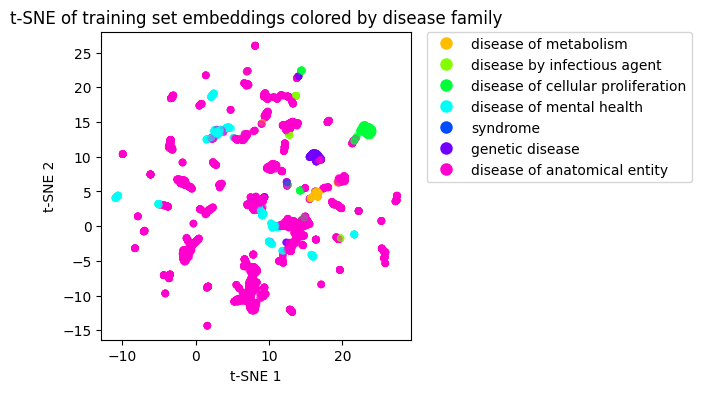

In [ ]:
import umap

# color by family
num_colors = len(set(fams))
color_palette = sns.color_palette("hsv", num_colors)
color_map = {fam: color_palette[i] for i, fam in enumerate(sorted(set(fams)))}
colors = [color_map[fam] for fam in fams]   
# plot umap
# import tsne
from sklearn.manifold import TSNE
reducer = umap.UMAP(
    # n_neighbors=15, 
    # min_dist=0.1,
    metric='cosine')
embedding = reducer.fit_transform(embeddings_train[idxs])
# embedding = reducer.fit_transform(np.nan_to_num(adata_train.X[idxs], 0))

# plot
plt.figure(figsize=(4,4))
plt.scatter(embedding[:,0], embedding[:,1], c=colors, s=20, alpha=0.5)
# create legend
handles = [plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=color_map[fam], markersize=10) for fam in sorted(set(fams))]
plt.legend(handles, [doid_to_term[fam] for fam in sorted(set(fams))], bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)
plt.title("t-SNE of training set embeddings colored by disease family")
plt.xlabel("t-SNE 1")
plt.ylabel("t-SNE 2")

In [ ]:
import umap
def get_reduced_embs(X, method="umap", rand_state=42):
    if method == "umap":
        reducer = umap.UMAP(
            n_components=2,
            n_neighbors=20,
            min_dist=0.9,
            metric='cosine',
            # random_state=rand_state,
            n_jobs=8,
            )
        embedding = reducer.fit_transform(X)
    elif method == "tsne":
        tsne = TSNE(
            n_components=2,
            metric='cosine',
            random_state=rand_state,
        )
        embedding = tsne.fit_transform(X)
    return embedding

embedding = get_reduced_embs(embeddings_train, method="umap")
embedding_gex = get_reduced_embs(np.nan_to_num(adata_train.X, 0), method="umap")
embedding_pt = get_reduced_embs(pt_train_embedd, method="umap")


In [9]:
# Load IC based similarity 
do_graph = ut.load_do_graph()
doid_to_term = {
    node: data["name"] for node, data in do_graph.nodes(data=True) if "name" in data
}


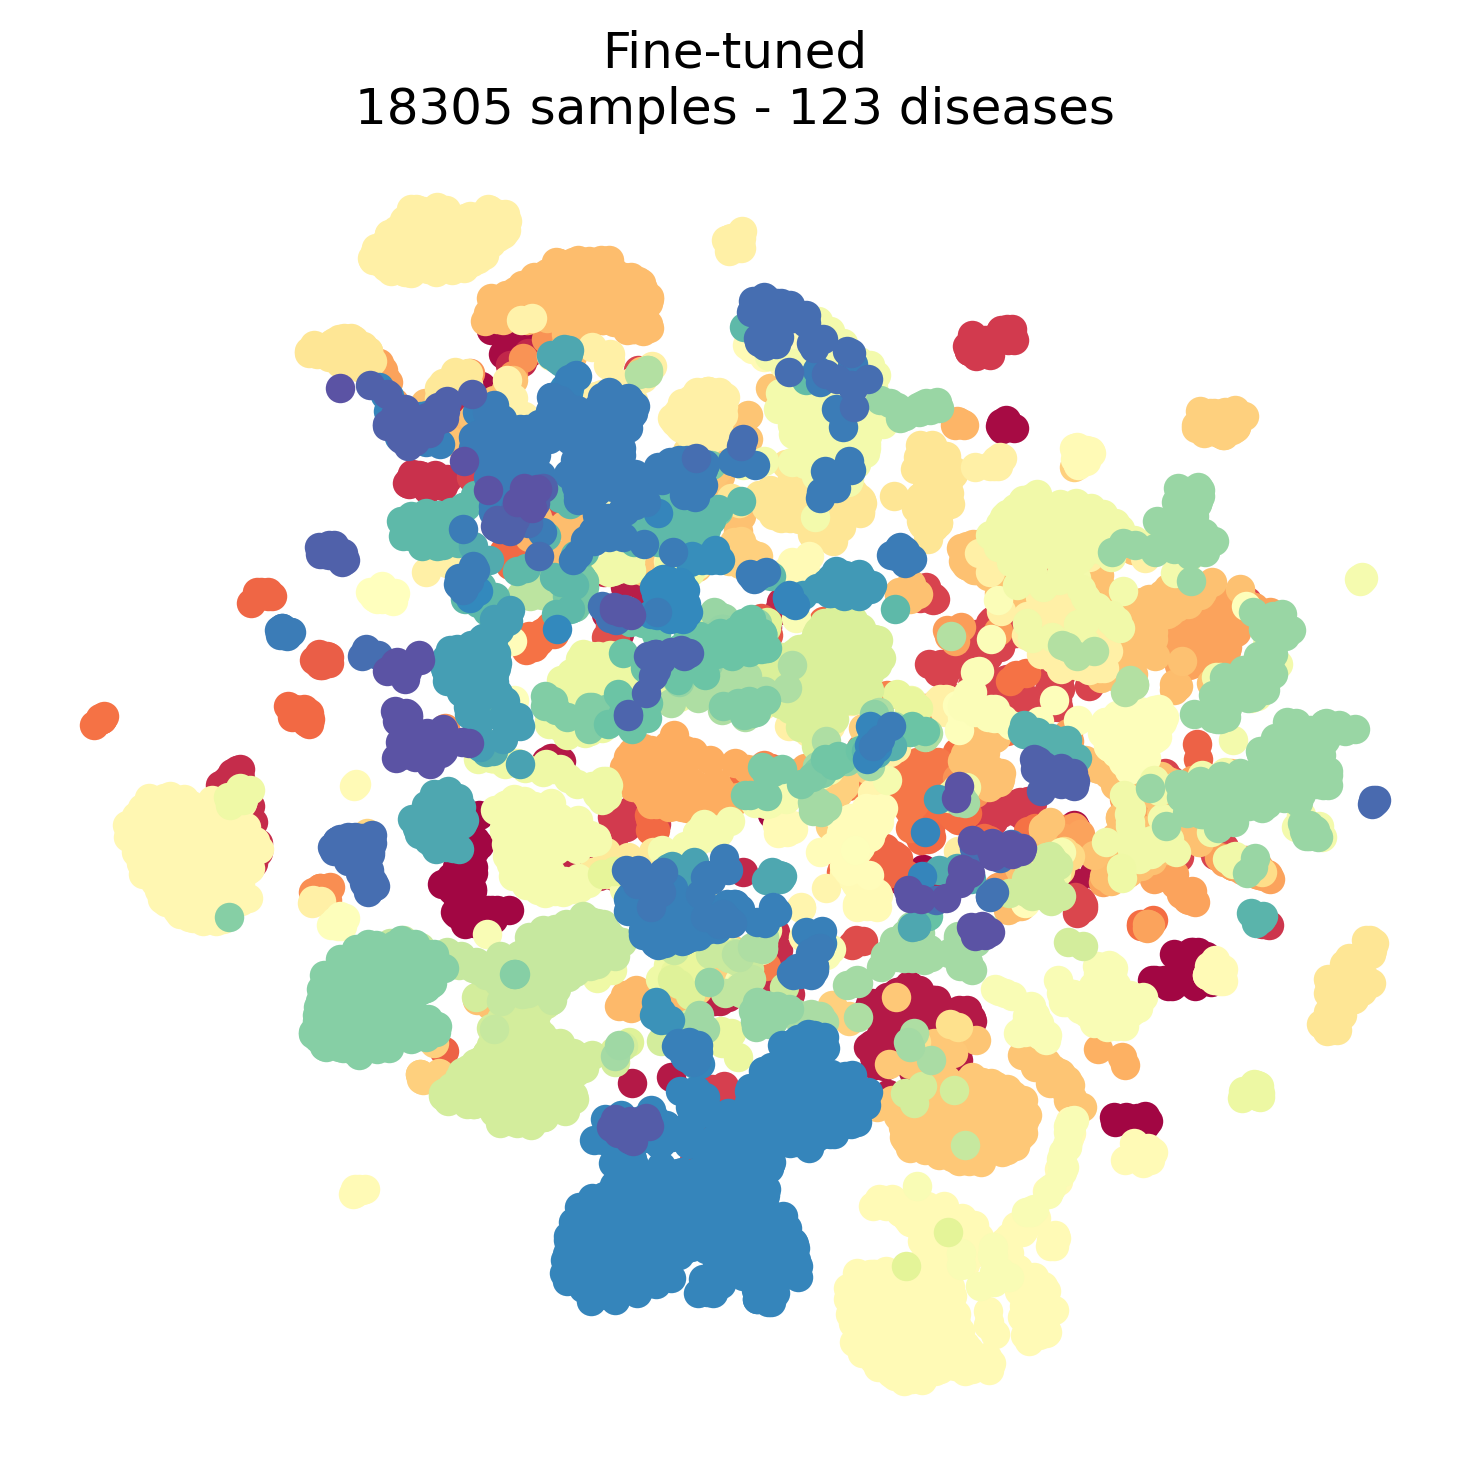

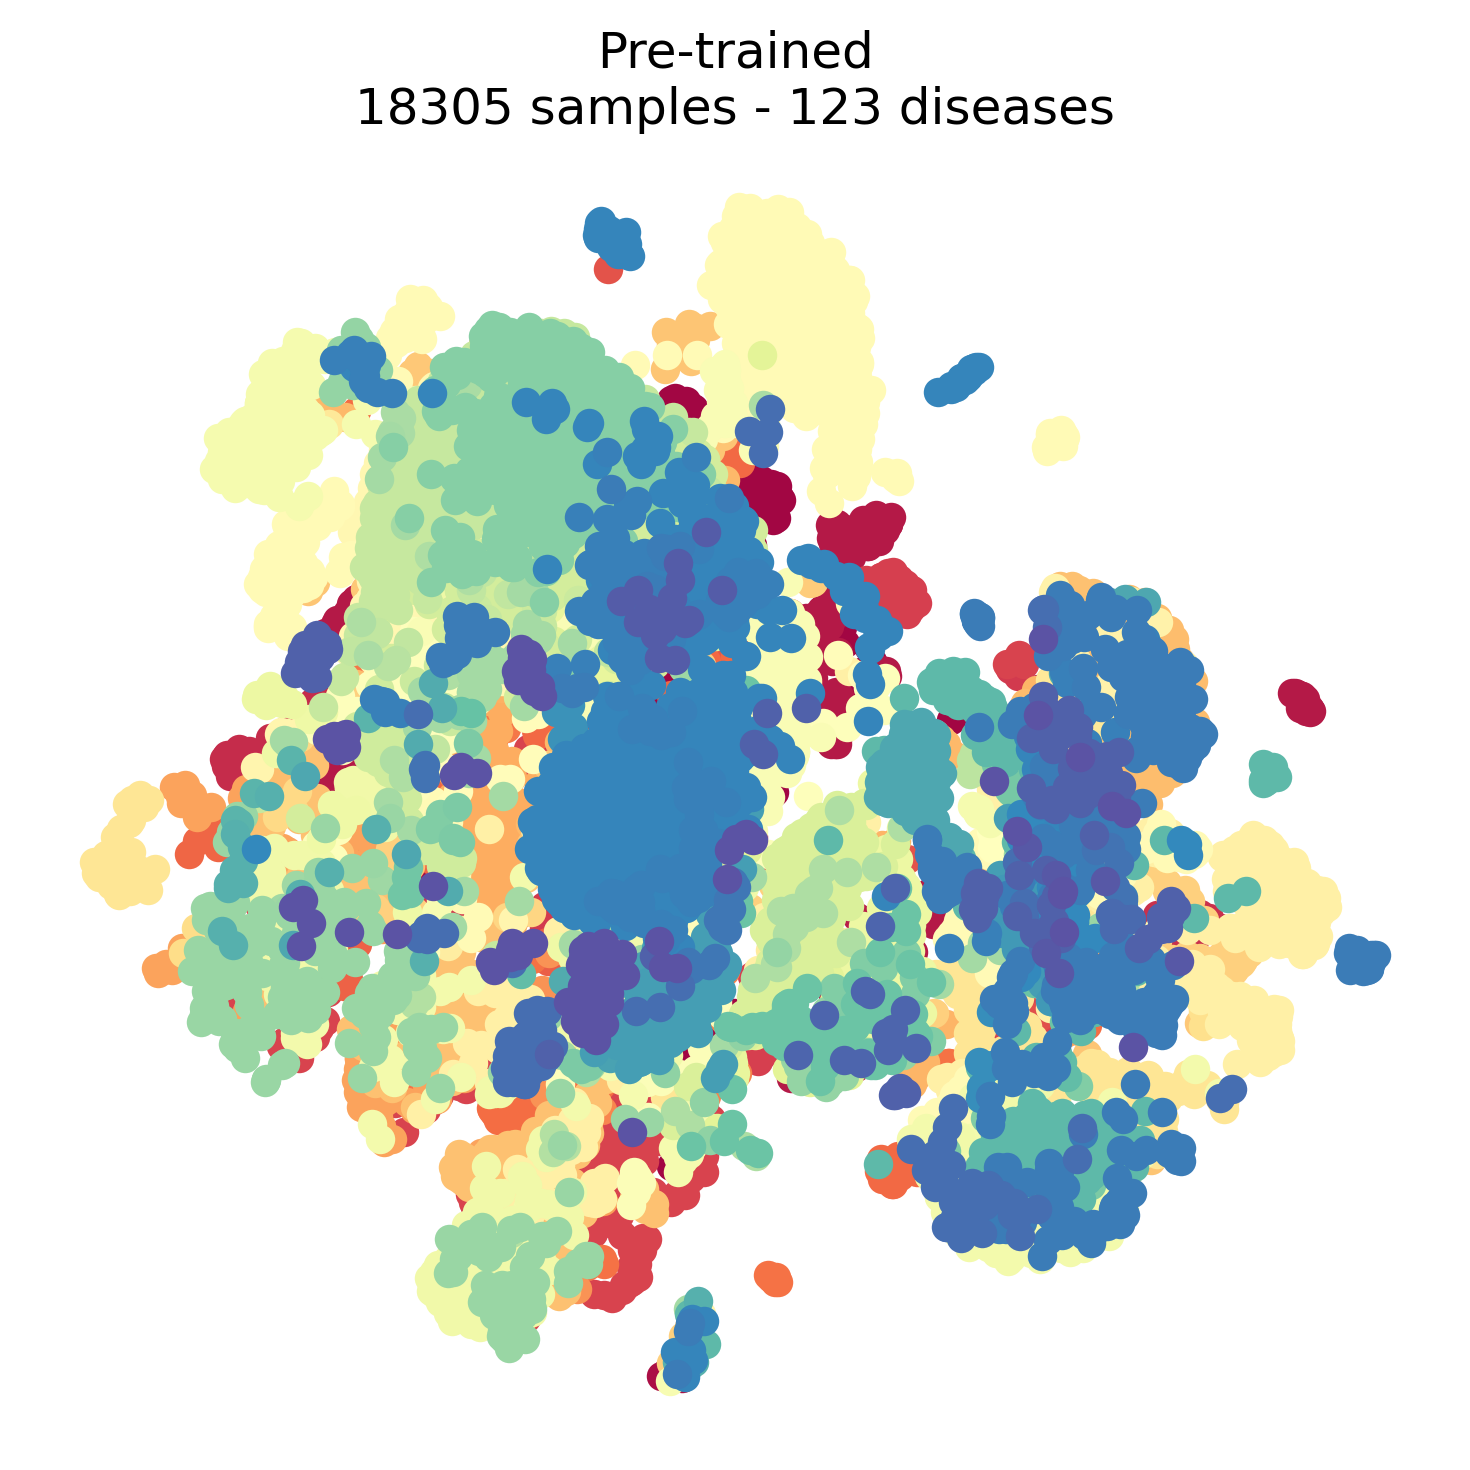

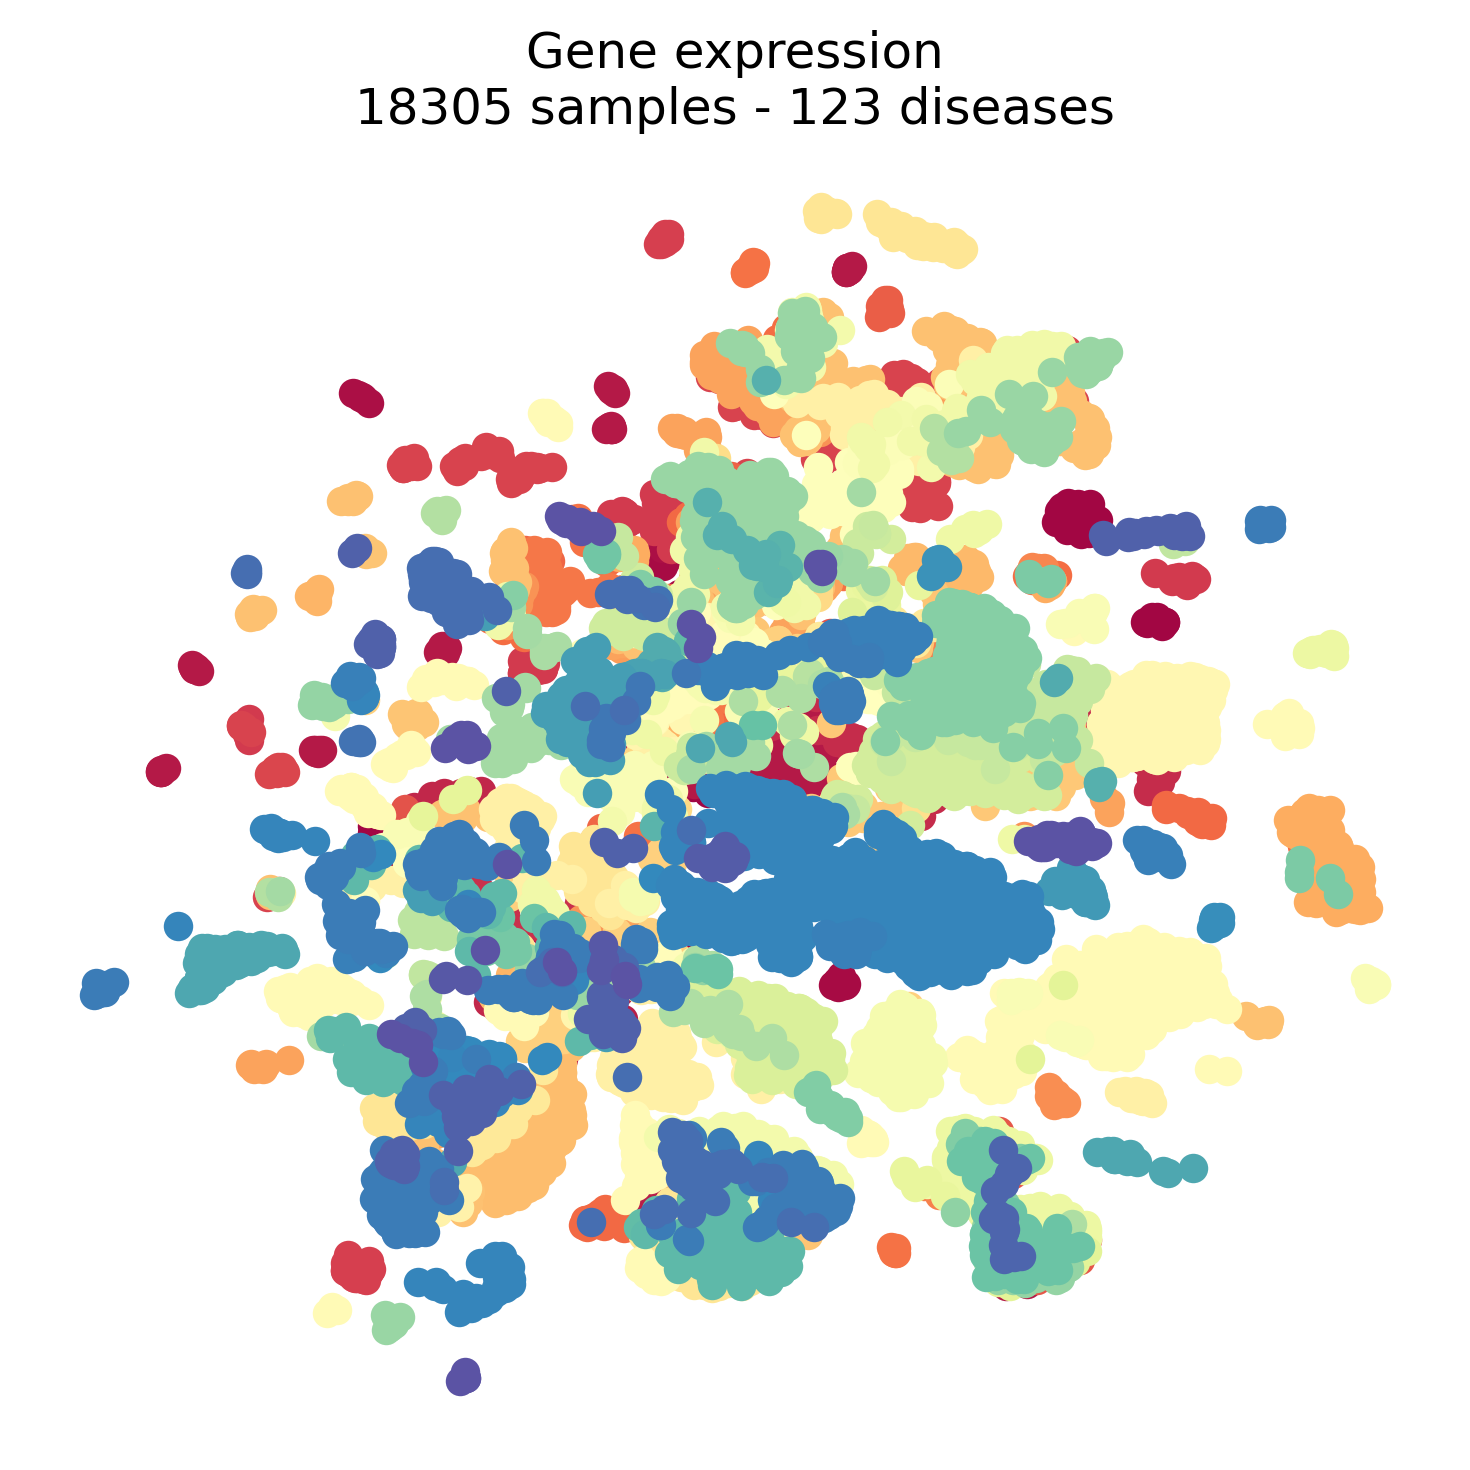

In [49]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ---------------------------------------------------------------------
# 0) masks (your current example sets ALL to interest; adapt as needed)
dataset_interest = "GSE89843"

# example: toggle interest mask here
# mask_fam = (adata_train.obs["dataset"] == dataset_interest).to_numpy()
mask_fam = np.ones(adata_train.shape[0], dtype=bool)

idx_rest = np.where(~mask_fam)[0]
idx_interest = np.where(mask_fam)[0]

# ---------------------------------------------------------------------
# 1) Build ONE color map: disease (DOID) -> color (skip "Control")
doids_interest = adata_train.obs.loc[idx_interest, 'doid_id'].unique().tolist()
doids_interest = [d for d in doids_interest if d != "Control"]

# stable order
doids_interest = sorted(doids_interest)

palette = sns.color_palette("Spectral", max(len(doids_interest), 1))
disease_color_map = {doid: palette[i % len(palette)] for i, doid in enumerate(doids_interest)}

# helper for label lookup
def disease_label(doid):
    return doid_to_term.get(doid, doid)

# ---------------------------------------------------------------------
# 2) Helper to plot one panel using the shared color map
def plot_panel(embedding_2d, title):
    plt.figure(figsize=(5, 5), dpi=300)

    # background (rest) in grey
    if idx_rest.size > 0:
        plt.scatter(embedding_2d[idx_rest, 0], embedding_2d[idx_rest, 1],
                    c='grey', s=2, alpha=0.6, zorder=1, linewidths=0)

    # foreground (interest) by disease color
    for doid in doids_interest:
        idx_i = np.where(adata_train.obs['doid_id'].to_numpy() == doid)[0]
        if idx_i.size == 0:
            continue
        plt.scatter(embedding_2d[idx_i, 0], embedding_2d[idx_i, 1],
                    c=[disease_color_map[doid]], s=50, alpha=1, zorder=3,
                    linewidths=0, label=disease_label(doid))

    # legend (only diseases we actually plotted)
    # if len(doids_interest) > 0:
    #     plt.legend(title="Diseases", bbox_to_anchor=(1.02, 1),
    #                loc='upper left', frameon=False)

    plt.xticks([])
    plt.yticks([])
    plt.xlabel("")
    plt.ylabel("")
    plt.gca().tick_params(left=False, bottom=False, labelleft=False, labelbottom=False)
    for spine in plt.gca().spines.values():
        spine.set_visible(False)


    plt.title(title)
    # plt.xlabel("t-SNE 1")
    # plt.ylabel("t-SNE 2")
    plt.tight_layout()
    plt.show()

# ---------------------------------------------------------------------
# 3) Plot all three with the SAME disease->color mapping
plot_panel(embedding,    f"Fine-tuned\n{len(adata_train)} samples - {len(doids_interest)} diseases")
plot_panel(embedding_pt, f"Pre-trained\n{len(adata_train)} samples - {len(doids_interest)} diseases")
plot_panel(embedding_gex,f"Gene expression\n{len(adata_train)} samples - {len(doids_interest)} diseases")


/tmp/ipykernel_15367/639378640.py:18: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  plt.scatter(embedding[idx_interest,0], embedding[idx_interest,1], c=color_palette[i], s=25, alpha=0.5, zorder=3)
/tmp/ipykernel_15367/639378640.py:23: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


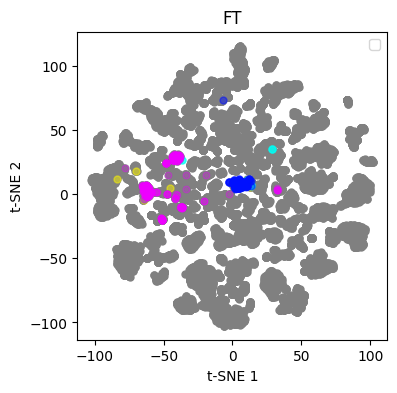

/tmp/ipykernel_15367/639378640.py:39: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  plt.scatter(embedding_gex[idx_interest,0], embedding_gex[idx_interest,1], c=color_palette[i], s=25, alpha=0.5, zorder=3)
/tmp/ipykernel_15367/639378640.py:44: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


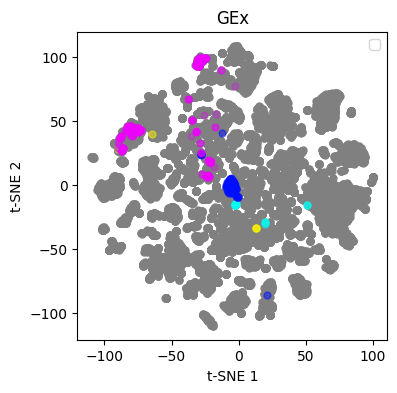

In [ ]:
# disease specific UMAP

doids_interest = ["DOID:848","DOID:7148","DOID:7147"]
doids_interest = ["DOID:2841", "DOID:9415", "DOID:850"]
doids_interests = ["DOID:0050700","DOID:11984","DOID:12930"]
doids_interest = ["DOID:5015","DOID:684","DOID:687"]
doids_interest = ["DOID:7147","DOID:7148","DOID:8398","DOID:848","DOID:7148"]

# plot
plt.figure(figsize=(4,4))
idx_rest = np.where(~adata_train.obs['doid_id'].isin(doids_interest))[0]
plt.scatter(embedding[idx_rest,0], embedding[idx_rest,1], c='grey', s=25, alpha=1, zorder=1)

num_colors = len(doids_interest)
color_palette = sns.color_palette("hsv", num_colors)
for i, doid_interest in enumerate(doids_interest):
    idx_interest = np.where(adata_train.obs['doid_id']==doid_interest)[0]
    plt.scatter(embedding[idx_interest,0], embedding[idx_interest,1], c=color_palette[i], s=25, alpha=0.5, zorder=3)

# create legend
# handles = [plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=color_map[fam], markersize=10) for fam in sorted(set(fams))]
# plt.legend(handles, [doid_to_term[fam] for fam in sorted(set(fams))], bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)
plt.legend()
plt.title("FT")
plt.xlabel("t-SNE 1")
plt.ylabel("t-SNE 2")
plt.show()


# plot
plt.figure(figsize=(4,4))
idx_rest = np.where(~adata_train.obs['doid_id'].isin(doids_interest))[0]
plt.scatter(embedding_gex[idx_rest,0], embedding_gex[idx_rest,1], c='grey', s=25, alpha=1, zorder=1)

num_colors = len(doids_interest)
color_palette = sns.color_palette("hsv", num_colors)
for i, doid_interest in enumerate(doids_interest):
    idx_interest = np.where(adata_train.obs['doid_id']==doid_interest)[0]
    plt.scatter(embedding_gex[idx_interest,0], embedding_gex[idx_interest,1], c=color_palette[i], s=25, alpha=0.5, zorder=3)

# create legend
# handles = [plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=color_map[fam], markersize=10) for fam in sorted(set(fams))]
# plt.legend(handles, [doid_to_term[fam] for fam in sorted(set(fams))], bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)
plt.legend()
plt.title("GEx")
plt.xlabel("t-SNE 1")
plt.ylabel("t-SNE 2")
plt.show()

In [237]:
adata_train.obs[adata_train.obs["dataset"] == "GSE89843"]["disease"].unique()

['Control', 'Non-Small Cell Lung Cancer', 'Multiple Sclerosis', 'Atherosclerosis']
Categories (135, object): ['Acne Inversa', 'Acquired Immunodeficiency Syndrome', 'Acute Lymphoblastic Leukemia', 'Acute Myeloid Leukemia', ..., 'Type 2 Diabetes', 'Ulcerative Colitis', 'Williams Syndrome', 'Williams-Beuren Syndrome']

In [225]:
adata_train.obs.groupby("dataset")["doid_id"].nunique()

/tmp/ipykernel_15367/1621815864.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  adata_train.obs.groupby("dataset")["doid_id"].nunique()


dataset
E-MTAB-1030    2
E-MTAB-4586    2
E-MTAB-5464    2
E-MTAB-7145    2
E-MTAB-7860    2
              ..
TCGA-COAD      2
TCGA-GBM       2
TCGA-HNSC      2
TCGA-LUAD      2
TCGA-PRAD      2
Name: doid_id, Length: 471, dtype: int64

/tmp/ipykernel_15367/3925476638.py:42: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  plt.scatter(embedding[idx_i,0], embedding[idx_i,1], c=color_palette[i], s=35, alpha=1, zorder=3,label=doid_to_term.get(doid_interest))


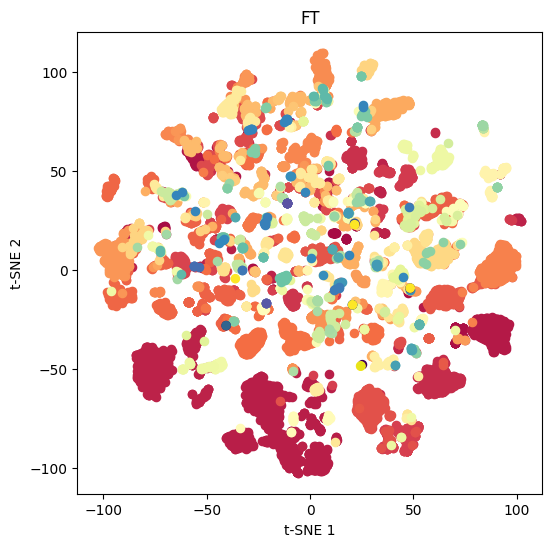

/tmp/ipykernel_15367/3925476638.py:81: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  plt.scatter(embedding_gex[idx_i,0], embedding_gex[idx_i,1], c=color_palette[i], s=35, alpha=1, zorder=3,label=doid_to_term.get(doid_interest))


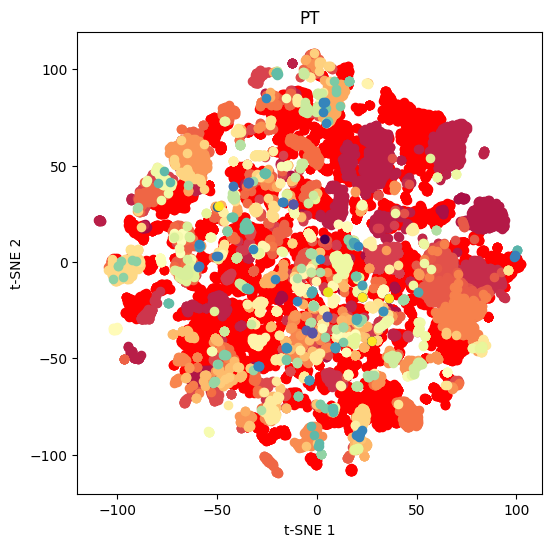

/tmp/ipykernel_15367/3925476638.py:118: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  plt.scatter(embedding_gex[idx_i,0], embedding_gex[idx_i,1], c=color_palette[i], s=35, alpha=1, zorder=3, label=doid_to_term.get(doid_interest))


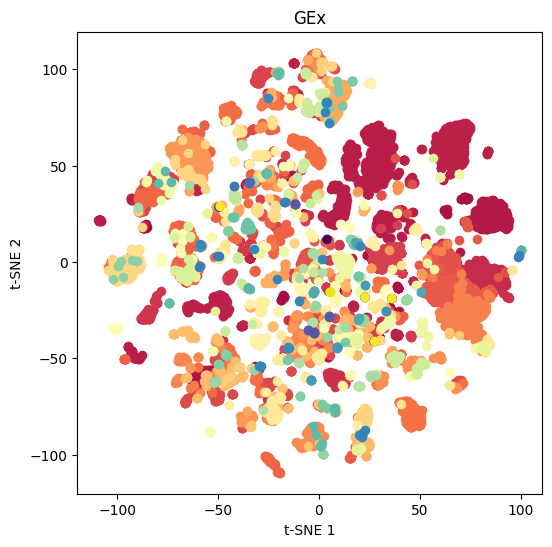

In [ ]:
from scipy.stats import gaussian_kde

adata_train.obs.reset_index(drop=True, inplace=True)
plt.figure(figsize=(6,6))

dataset_interest = "GSE89843"

mask_fam = np.array(adata_train.obs["dataset"]==dataset_interest)

idx_rest = np.where(~mask_fam)[0]
idx_interest = np.where(mask_fam)[0]


# disease specific UMAP

# plot
plt.scatter(embedding[idx_rest,0], embedding[idx_rest,1], c='grey', s=35, alpha=1, zorder=1)
# plt.scatter(embedding[idx_interest,0], embedding[idx_interest,1], c="red", s=35, alpha=1, zorder=3)
# density on the interest subset
# pts = embedding[idx_interest].T  # shape (2, n)
# kde = gaussian_kde(pts)          # Scott’s rule bw by default
# z = kde(pts)                     # density per point

# # normalize to [0,1] and map to Reds (light red -> dark red)
# z_norm = (z - z.min()) / (z.ptp() + 1e-12)
# colors = plt.cm.Reds(0.4+0.5*z_norm)  # avoid too-pale values

# # draw low density first, high density last
# order = np.argsort(z)
# idx_ordered = idx_interest[order]

# plt.scatter(embedding[idx_ordered, 0], embedding[idx_ordered, 1],
#             c=colors[order], s=35, alpha=0.9, zorder=3, linewidths=0)

doids_interest = adata_train.obs['doid_id'][idx_interest].unique()
num_colors = len(doids_interest)
color_palette = sns.color_palette("rocket_r", num_colors)
for i, doid_interest in enumerate(doids_interest):
    if doid_interest == "Control":
        continue
    idx_i = np.where(adata_train.obs['doid_id']==doid_interest)[0]
    plt.scatter(embedding[idx_i,0], embedding[idx_i,1], c=color_palette[i], s=35, alpha=1, zorder=3,label=doid_to_term.get(doid_interest))

plt.legend()
plt.title("FT")
plt.xlabel("t-SNE 1")
plt.ylabel("t-SNE 2")
plt.show()




plt.figure(figsize=(6,6))

# plot
plt.scatter(embedding_pt[idx_rest,0], embedding_pt[idx_rest,1], c='grey', s=35, alpha=1, zorder=1)
# density on the interest subset
# pts = embedding_pt[idx_interest].T  # shape (2, n)
# kde = gaussian_kde(pts)          # Scott’s rule bw by default
# z = kde(pts)                     # density per point

# # normalize to [0,1] and map to Reds (light red -> dark red)
# z_norm = (z - z.min()) / (z.ptp() + 1e-12)
# colors = plt.cm.Reds(0.4+0.5*z_norm)  # avoid too-pale values

# # draw low density first, high density last
# order = np.argsort(z)
# idx_ordered = idx_interest[order]

# plt.scatter(embedding_pt[idx_ordered, 0], embedding_pt[idx_ordered, 1],
#             c=colors[order], s=35, alpha=0.9, zorder=3, linewidths=0)

plt.scatter(embedding_pt[idx_interest,0], embedding_pt[idx_interest,1], c="red", s=35, alpha=1, zorder=3)
doids_interest = adata_train.obs['doid_id'][idx_interest].unique()
num_colors = len(doids_interest)
color_palette = sns.color_palette("rocket_r", num_colors)
for i, doid_interest in enumerate(doids_interest):
    if doid_interest == "Control":
        continue
    idx_i = np.where(adata_train.obs['doid_id']==doid_interest)[0]
    plt.scatter(embedding_gex[idx_i,0], embedding_gex[idx_i,1], c=color_palette[i], s=35, alpha=1, zorder=3,label=doid_to_term.get(doid_interest))

plt.legend()
plt.title("PT")
plt.xlabel("t-SNE 1")
plt.ylabel("t-SNE 2")
plt.show()



plt.figure(figsize=(6,6))

# plot
plt.scatter(embedding_gex[idx_rest,0], embedding_gex[idx_rest,1], c='grey', s=35, alpha=1, zorder=1)
# plt.scatter(embedding_gex[idx_interest,0], embedding_gex[idx_interest,1], c="red", s=35, alpha=1, zorder=3)
# pts = embedding_gex[idx_interest].T  # shape (2, n)
# kde = gaussian_kde(pts)          # Scott’s rule bw by default
# z = kde(pts)                     # density per point

# # normalize to [0,1] and map to Reds (light red -> dark red)
# z_norm = (z - z.min()) / (z.ptp() + 1e-12)
# colors = plt.cm.Reds(0.4+0.5*z_norm)  # avoid too-pale values

# # draw low density first, high density last
# order = np.argsort(z)
# idx_ordered = idx_interest[order]

# plt.scatter(embedding_gex[idx_ordered, 0], embedding_gex[idx_ordered, 1],
#             c=colors[order], s=35, alpha=0.9, zorder=3, linewidths=0)

doids_interest = adata_train.obs['doid_id'][idx_interest].unique()
num_colors = len(doids_interest)
color_palette = sns.color_palette("rocket_r", num_colors)
for i, doid_interest in enumerate(doids_interest):
    if doid_interest == "Control":
        continue
    idx_i = np.where(adata_train.obs['doid_id']==doid_interest)[0]
    plt.scatter(embedding_gex[idx_i,0], embedding_gex[idx_i,1], c=color_palette[i], s=35, alpha=1, zorder=3, label=doid_to_term.get(doid_interest))

plt.legend()
plt.title("GEx")
plt.xlabel("t-SNE 1")
plt.ylabel("t-SNE 2")
plt.show()

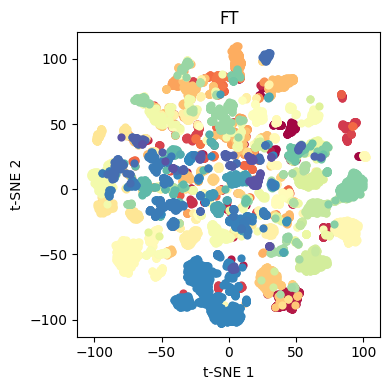

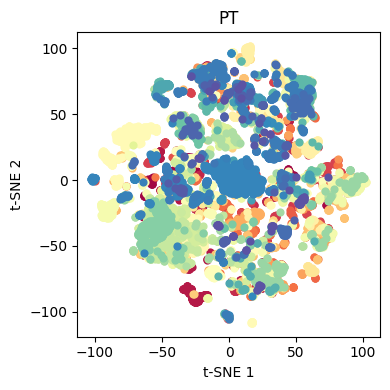

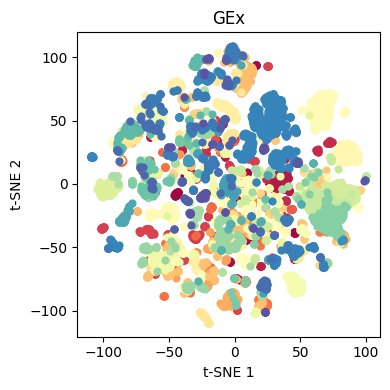

In [ ]:
from scipy.stats import gaussian_kde

adata_train.obs.reset_index(drop=True, inplace=True)
plt.figure(figsize=(6,6))

fam_interest = "DOID:14566"

mask_fam = list()
for doid in adata_train.obs["doid_id"]:
    if doid not in do_graph:
        mask_fam.append(False)
    elif nx.has_path(do_graph, fam_interest, doid):
        mask_fam.append(True)
    else:
        mask_fam.append(False)
mask_fam = np.array(mask_fam)

idx_rest = np.where(~mask_fam)[0]
idx_interest = np.where(mask_fam)[0]


# disease specific UMAP

# plot
plt.scatter(embedding[idx_rest,0], embedding[idx_rest,1], c='grey', s=35, alpha=1, zorder=1)
# plt.scatter(embedding[idx_interest,0], embedding[idx_interest,1], c="red", s=35, alpha=0.5, zorder=3)
# density on the interest subset
# pts = embedding[idx_interest].T  # shape (2, n)
# kde = gaussian_kde(pts)          # Scott’s rule bw by default
# z = kde(pts)                     # density per point

# # normalize to [0,1] and map to Reds (light red -> dark red)
# z_norm = (z - z.min()) / (z.ptp() + 1e-12)
# colors = plt.cm.Reds(0.4+0.5*z_norm)  # avoid too-pale values

# # draw low density first, high density last
# order = np.argsort(z)
# idx_ordered = idx_interest[order]

# plt.scatter(embedding[idx_ordered, 0], embedding[idx_ordered, 1],
#             c=colors[order], s=35, alpha=0.9, zorder=3, linewidths=0)

doids_interest = adata_train.obs['doid_id'][idx_interest].unique()
num_colors = len(doids_interest)
color_palette = sns.color_palette("rocket_r", num_colors)
for i, doid_interest in enumerate(doids_interest):
    idx_i = np.where(adata_train.obs['doid_id']==doid_interest)[0]
    plt.scatter(embedding[idx_i,0], embedding[idx_i,1], c=color_palette[i], s=35, alpha=0.5, zorder=3)

plt.legend()
plt.title("FT")
plt.xlabel("t-SNE 1")
plt.ylabel("t-SNE 2")
plt.show()




plt.figure(figsize=(6,6))

# plot
plt.scatter(embedding_pt[idx_rest,0], embedding_pt[idx_rest,1], c='grey', s=35, alpha=1, zorder=1)
# density on the interest subset
# pts = embedding_pt[idx_interest].T  # shape (2, n)
# kde = gaussian_kde(pts)          # Scott’s rule bw by default
# z = kde(pts)                     # density per point

# # normalize to [0,1] and map to Reds (light red -> dark red)
# z_norm = (z - z.min()) / (z.ptp() + 1e-12)
# colors = plt.cm.Reds(0.4+0.5*z_norm)  # avoid too-pale values

# # draw low density first, high density last
# order = np.argsort(z)
# idx_ordered = idx_interest[order]

# plt.scatter(embedding_pt[idx_ordered, 0], embedding_pt[idx_ordered, 1],
#             c=colors[order], s=35, alpha=0.9, zorder=3, linewidths=0)

plt.scatter(embedding_pt[idx_interest,0], embedding_pt[idx_interest,1], c="red", s=35, alpha=0.5, zorder=3)
doids_interest = adata_train.obs['doid_id'][idx_interest].unique()
num_colors = len(doids_interest)
color_palette = sns.color_palette("rocket_r", num_colors)
for i, doid_interest in enumerate(doids_interest):
    idx_i = np.where(adata_train.obs['doid_id']==doid_interest)[0]
    plt.scatter(embedding_gex[idx_i,0], embedding_gex[idx_i,1], c=color_palette[i], s=35, alpha=0.5, zorder=3)

plt.legend()
plt.title("PT")
plt.xlabel("t-SNE 1")
plt.ylabel("t-SNE 2")
plt.show()



plt.figure(figsize=(6,6))

# plot
plt.scatter(embedding_gex[idx_rest,0], embedding_gex[idx_rest,1], c='grey', s=35, alpha=1, zorder=1)
# plt.scatter(embedding_gex[idx_interest,0], embedding_gex[idx_interest,1], c="red", s=35, alpha=0.5, zorder=3)
# pts = embedding_gex[idx_interest].T  # shape (2, n)
# kde = gaussian_kde(pts)          # Scott’s rule bw by default
# z = kde(pts)                     # density per point

# # normalize to [0,1] and map to Reds (light red -> dark red)
# z_norm = (z - z.min()) / (z.ptp() + 1e-12)
# colors = plt.cm.Reds(0.4+0.5*z_norm)  # avoid too-pale values

# # draw low density first, high density last
# order = np.argsort(z)
# idx_ordered = idx_interest[order]

# plt.scatter(embedding_gex[idx_ordered, 0], embedding_gex[idx_ordered, 1],
#             c=colors[order], s=35, alpha=0.9, zorder=3, linewidths=0)

doids_interest = adata_train.obs['doid_id'][idx_interest].unique()
num_colors = len(doids_interest)
color_palette = sns.color_palette("rocket_r", num_colors)
for i, doid_interest in enumerate(doids_interest):
    idx_i = np.where(adata_train.obs['doid_id']==doid_interest)[0]
    plt.scatter(embedding_gex[idx_i,0], embedding_gex[idx_i,1], c=color_palette[i], s=35, alpha=0.5, zorder=3)

plt.legend()
plt.title("GEx")
plt.xlabel("t-SNE 1")
plt.ylabel("t-SNE 2")
plt.show()

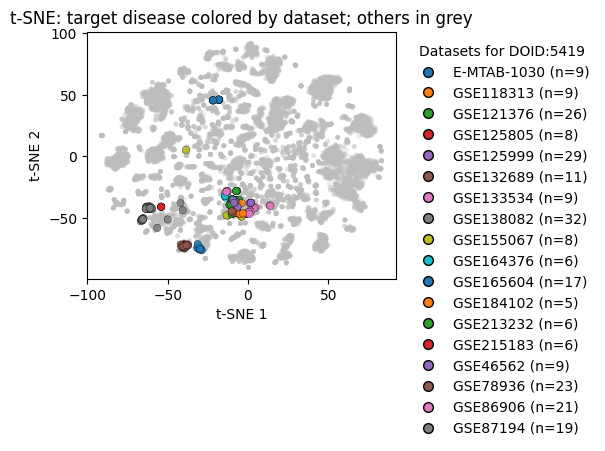

In [129]:
# disease specific t-SNE / UMAP (using your existing t-SNE embedding)
doid_interest = "DOID:5419"

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# indices
idx_interest = np.where(adata_train.obs['doid_id'] == doid_interest)[0]
idx_rest     = np.where(adata_train.obs['doid_id'] != doid_interest)[0]

# choose the column that identifies dataset/study
# change 'dataset' to your actual column if different (e.g., 'study')
ds_col = 'dataset'
ds_interest = adata_train.obs.iloc[idx_interest][ds_col].astype(str).values
unique_ds = sorted(pd.unique(ds_interest))

# color map only for datasets present in this disease
palette = sns.color_palette("tab10", len(unique_ds))
ds_color_map = {ds: palette[i] for i, ds in enumerate(unique_ds)}

# build a color array for all points: grey for rest, dataset colors for interest
colors_all = np.full(embedding.shape[0], "#BDBDBD", dtype=object)  # rest = grey
for i, idx in enumerate(idx_interest):
    colors_all[idx] = ds_color_map[ds_interest[i]]

plt.figure(figsize=(6,4))

# plot: rest first (background), then disease points with edges (foreground)
plt.scatter(embedding[idx_rest, 0], embedding[idx_rest, 1],
            c=colors_all[idx_rest], s=12, alpha=0.25, lw=0, zorder=1, label=None)

plt.scatter(embedding[idx_interest, 0], embedding[idx_interest, 1],
            c=colors_all[idx_interest], s=28, alpha=0.9,
            edgecolors="k", linewidths=0.25, zorder=3, label=None)

# legend: only datasets present in the disease subset, with counts
from collections import Counter
cnts = Counter(ds_interest)
handles = [
    plt.Line2D([0], [0], marker='o', linestyle='',
               markerfacecolor=ds_color_map[ds], markeredgecolor='k',
               markersize=7, label=f"{ds} (n={cnts[ds]})")
    for ds in unique_ds
]
plt.legend(handles=handles, title=f"Datasets for {doid_interest}",
           bbox_to_anchor=(1.02, 1), loc='upper left', frameon=False)

plt.title("t-SNE: target disease colored by dataset; others in grey")
plt.xlabel("t-SNE 1"); plt.ylabel("t-SNE 2"); plt.tight_layout()
plt.show()


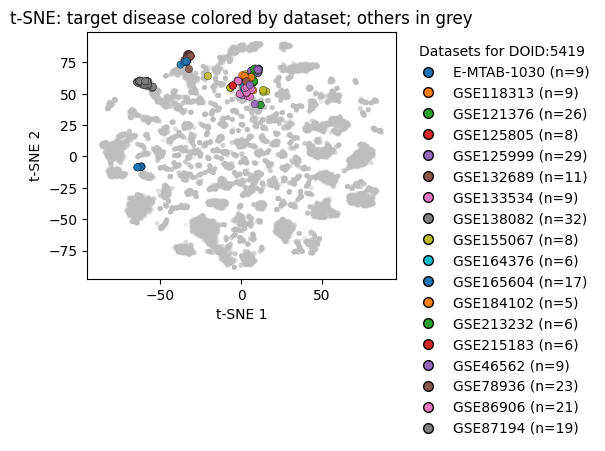

/home/ddalton/Data/old_home/miniconda3/envs/scgpt_2/lib/python3.12/site-packages/sklearn/manifold/_t_sne.py:1162: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(
/tmp/ipykernel_15367/3525186000.py:43: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


Text(0, 0.5, 't-SNE 2')

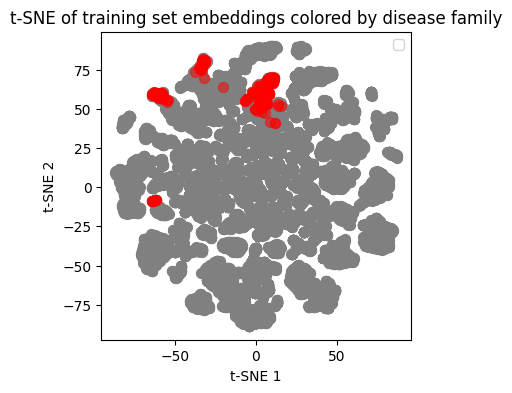

In [ ]:
# disease specific UMAP

doid_interest = "DOID:5419"

import umap

# color by family
num_colors = len(set(fams))
color_palette = sns.color_palette("hsv", num_colors)
color_map = {fam: color_palette[i] for i, fam in enumerate(sorted(set(fams)))}
colors = [color_map[fam] for fam in fams]   
# plot umap
# import tsne
from sklearn.manifold import TSNE
# reducer = umap.UMAP(
#     # n_neighbors=15, 
#     # min_dist=0.1,
#     metric='cosine')
# # embedding = reducer.fit_transform(embeddings_train)
# embedding = reducer.fit_transform(np.nan_to_num(adata_train.X, 0))

tsne = TSNE(
    n_components=2,
    perplexity=30,
    learning_rate=200,
    n_iter=1000,
    metric='cosine',
    random_state=42,
)
embedding = tsne.fit_transform(embeddings_train) 

# plot
plt.figure(figsize=(4,4))
idx_interest = np.where(adata_train.obs['doid_id']==doid_interest)[0]
idx_rest = np.where(adata_train.obs['doid_id']!=doid_interest)[0]
plt.scatter(embedding[idx_rest,0], embedding[idx_rest,1], c='grey', s=50, alpha=1, zorder=1)
plt.scatter(embedding[idx_interest,0], embedding[idx_interest,1], c='red', s=50, alpha=0.5, zorder=3)

# create legend
# handles = [plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=color_map[fam], markersize=10) for fam in sorted(set(fams))]
# plt.legend(handles, [doid_to_term[fam] for fam in sorted(set(fams))], bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)
plt.legend()
plt.title("t-SNE of training set embeddings colored by disease family")
plt.xlabel("t-SNE 1")
plt.ylabel("t-SNE 2")

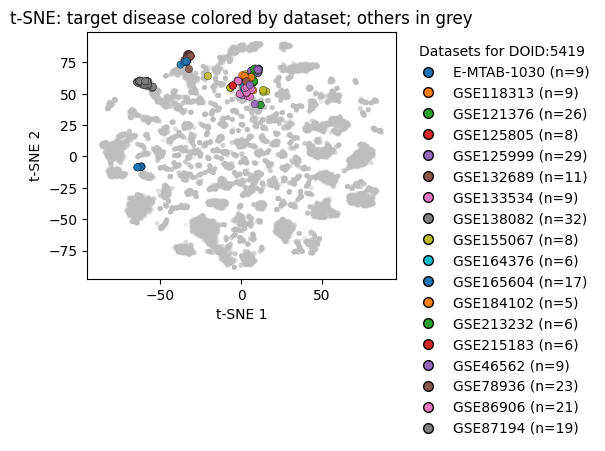

In [ ]:
# disease specific t-SNE / UMAP (using your existing t-SNE embedding)
doid_interest = "DOID:5419"

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# indices
idx_interest = np.where(adata_train.obs['doid_id'] == doid_interest)[0]
idx_rest     = np.where(adata_train.obs['doid_id'] != doid_interest)[0]

# choose the column that identifies dataset/study
# change 'dataset' to your actual column if different (e.g., 'study')
ds_col = 'dataset'
ds_interest = adata_train.obs.iloc[idx_interest][ds_col].astype(str).values
unique_ds = sorted(pd.unique(ds_interest))

# color map only for datasets present in this disease
palette = sns.color_palette("tab10", len(unique_ds))
ds_color_map = {ds: palette[i] for i, ds in enumerate(unique_ds)}

# build a color array for all points: grey for rest, dataset colors for interest
colors_all = np.full(embedding.shape[0], "#BDBDBD", dtype=object)  # rest = grey
for i, idx in enumerate(idx_interest):
    colors_all[idx] = ds_color_map[ds_interest[i]]

plt.figure(figsize=(6,4))

# plot: rest first (background), then disease points with edges (foreground)
plt.scatter(embedding[idx_rest, 0], embedding[idx_rest, 1],
            c=colors_all[idx_rest], s=12, alpha=0.25, lw=0, zorder=1, label=None)

plt.scatter(embedding[idx_interest, 0], embedding[idx_interest, 1],
            c=colors_all[idx_interest], s=28, alpha=0.9,
            edgecolors="k", linewidths=0.25, zorder=3, label=None)

# legend: only datasets present in the disease subset, with counts
from collections import Counter
cnts = Counter(ds_interest)
handles = [
    plt.Line2D([0], [0], marker='o', linestyle='',
               markerfacecolor=ds_color_map[ds], markeredgecolor='k',
               markersize=7, label=f"{ds} (n={cnts[ds]})")
    for ds in unique_ds
]
plt.legend(handles=handles, title=f"Datasets for {doid_interest}",
           bbox_to_anchor=(1.02, 1), loc='upper left', frameon=False)

plt.title("t-SNE: target disease colored by dataset; others in grey")
plt.xlabel("t-SNE 1"); plt.ylabel("t-SNE 2"); plt.tight_layout()
plt.show()
